# Importing Data

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from scikeras.wrappers import KerasClassifier
import keras
from keras import layers, regularizers, callbacks, optimizers
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
all_sheets = pd.read_excel('DiabetesCleaned.xlsx', sheet_name=None)

# Extract each sheet into individual Dataframes
train_transformed = all_sheets['Train Transformed Data']
val_transformed = all_sheets['Validate Transformed Data']
test_transformed = all_sheets['Test Transformed Data']

In [3]:
# Split features into X and Y for easier processing
target_column = 'Outcome'

# Split Train Transformed Data
X_train_transformed = train_transformed.drop(columns=[target_column])
y_train = train_transformed[target_column]

# Split Validation Transformed Data
X_val_transformed = val_transformed.drop(columns=[target_column])
y_val = val_transformed[target_column]

# Split Test Transformed Data
X_test_transformed = test_transformed.drop(columns=[target_column])
y_test = test_transformed[target_column]

# Modeling

## ROC AUC graph function


In [4]:
def get_roc_auc(y_true, y_scores):
    # Plot ROC AUC curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = roc_auc_score(y_true, y_scores)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

## Models to be train

In [5]:
import optuna
from optuna.integration import TFKerasPruningCallback
from sklearn.calibration import CalibratedClassifierCV
optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna.logging.disable_default_handler()

def create_keras_model():
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(X_train_transformed.shape[1],)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

models = {
    'LinearSVC': LinearSVC(random_state=42),
    'SVC': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'MLP': MLPClassifier(random_state=42, max_iter=1000),
    'LogisticRegression': LogisticRegression(random_state=42),
    'GaussianNB': GaussianNB(),
    'DeepMLP': KerasClassifier(model=create_keras_model, epochs=50, batch_size=32, verbose=0),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42)
}

# Results
results = []

## Models before tuning

In [6]:
needs_scaling = {
    'LinearSVC', 'SVC', 'KNN', 'MLP', 'LogisticRegression', 'GaussianNB', 'DeepMLP'
}

for model_name, model in models.items():
    if model_name in needs_scaling:
        # Create pipeline with scaling
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', model)
        ])
    else:
        # Create pipeline without scaling  
        pipe = Pipeline([
            ('classifier', model)
        ])
    
    # Fit and predict
    pipe.fit(X_train_transformed, y_train)
    y_val_predict = pipe.predict(X_val_transformed)
    y_test_predict = pipe.predict(X_test_transformed)
    
    print(f'{model_name} Validation Classification Report:')
    print(classification_report(y_val, y_val_predict))

    print(f'{model_name} Test Classification Report:')
    print(classification_report(y_test, y_test_predict))
    print("-"*50)

LinearSVC Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.34      0.98      0.51        53

    accuracy                           0.34       153
   macro avg       0.17      0.49      0.25       153
weighted avg       0.12      0.34      0.18       153

LinearSVC Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.34      0.96      0.50        54

    accuracy                           0.34       154
   macro avg       0.17      0.48      0.25       154
weighted avg       0.12      0.34      0.18       154

--------------------------------------------------
SVC Validation Classification Report:
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       100
           1       0.00      0.00      0.00        53

    accurac

## Models tuning

### LinearSVC

In [7]:
# Hyper parameter tuning for LinearSVC
def obj_linear_svc(trial):
    # Hyperparameter tuning suggestions for LinearSVC fields
    C = trial.suggest_float('C', 0.01, 100.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    loss = trial.suggest_categorical('loss', ['hinge', 'squared_hinge'])
    tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    max_iter = trial.suggest_int('max_iter', 1000, 10000, step=500)
    class_weight = trial.suggest_categorical('class_weight', [
        None, 'balanced', {0: 1.0, 1: 1.3}, {0: 1.0, 1: 1.5}
    ])

    # CONSTRAINTS BASED ON https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
    # If penalty is 'l1', force loss to be 'squared_hinge'
    if penalty == 'l1' and loss == 'hinge':
        loss = 'squared_hinge'
    
    # - penalty='l1': dual must be False
    # - penalty='l2' and loss='hinge': dual must be True
    # - penalty='l2' and loss='squared_hinge': dual can be True or False
    if penalty == 'l1':
        dual = False
    elif penalty == 'l2' and loss == 'hinge':
        dual = True
    else:
        dual = trial.suggest_categorical('dual', [True, False])
    
    # Define the model
    model = LinearSVC(
        C=C,
        penalty=penalty,
        loss=loss,
        dual=dual,
        tol=tol,
        max_iter=max_iter,
        class_weight=class_weight,
        random_state=42
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    # Get f1_score
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Use Optuna to optimize the LinearSVC model
study_linear_svc = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_linear_svc.optimize(obj_linear_svc, n_trials=100)

print(f"Best hyperparameters for LinearSVC: {study_linear_svc.best_params}")
print(f"Best f1_score for LinearSVC: {study_linear_svc.best_value}")

def solve_invalid_hyperparameters(params):
    params = params.copy()
    if params.get('penalty') == 'l1' and params.get('loss') == 'hinge':
        params['loss'] = 'squared_hinge'
    if params.get('penalty') == 'l1':
        params['dual'] = False
    elif params.get('penalty') == 'l2' and params.get('loss') == 'hinge':
        params['dual'] = True
    return params

# Train LinearSVC using best params 
best_linear_svc = LinearSVC(
    **solve_invalid_hyperparameters(study_linear_svc.best_params),
    random_state=42
)

best_linear_svc_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_linear_svc)
])

best_linear_svc_pipe.fit(X_train_transformed, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_linear_svc = best_linear_svc_pipe.predict(X_val_transformed)
y_test_pred_linear_svc = best_linear_svc_pipe.predict(X_test_transformed)

Best hyperparameters for LinearSVC: {'C': 0.08234993271042479, 'penalty': 'l2', 'loss': 'hinge', 'tol': 1.2409150910534741e-05, 'max_iter': 6000, 'class_weight': {0: 1.0, 1: 1.3}}
Best f1_score for LinearSVC: 0.747464698838157


LinearSVC Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.34      0.98      0.51        53

    accuracy                           0.34       153
   macro avg       0.17      0.49      0.25       153
weighted avg       0.12      0.34      0.18       153



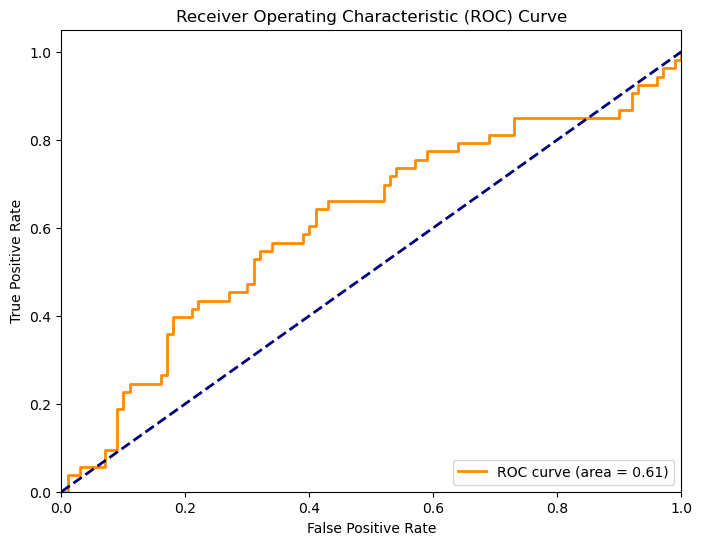

LinearSVC Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.34      0.96      0.50        54

    accuracy                           0.34       154
   macro avg       0.17      0.48      0.25       154
weighted avg       0.12      0.34      0.18       154



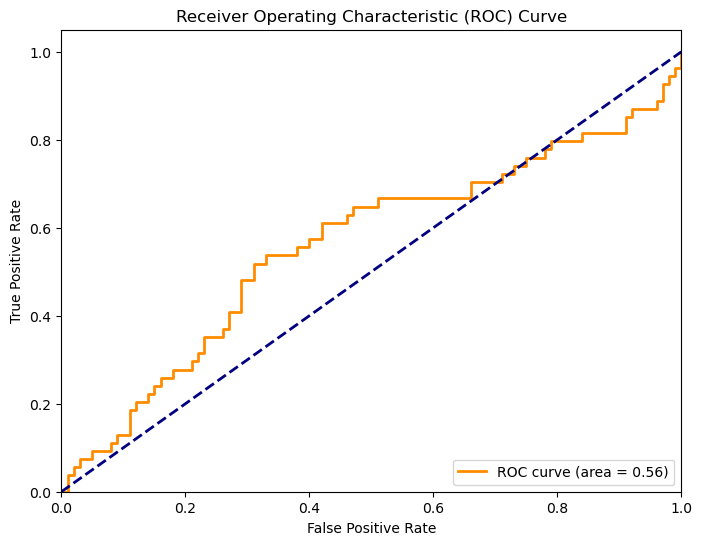

In [8]:
# Output
report_val = classification_report(y_val, y_val_pred_linear_svc, output_dict=True)
auc_val = roc_auc_score(y_val, best_linear_svc_pipe.decision_function(X_val_transformed))
print("LinearSVC Validation Classification Report:")
print(classification_report(y_val, y_val_pred_linear_svc))
get_roc_auc(y_val, best_linear_svc_pipe.decision_function(X_val_transformed))


report_test = classification_report(y_test, y_test_pred_linear_svc, output_dict=True)
auc_test = roc_auc_score(y_test, best_linear_svc_pipe.decision_function(X_test_transformed))
print("LinearSVC Test Classification Report:")
print(classification_report(y_test, y_test_pred_linear_svc))
get_roc_auc(y_test, best_linear_svc_pipe.decision_function(X_test_transformed))

results.append({
    "model": "LinearSVC",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### SVC

In [9]:
# Hyper parameter tuning for SVC
def obj_svc(trial):
    # Hyperparameter tuning suggestions for SVC fields
    C = trial.suggest_float('C', 0.01, 100.0, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
    degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 1
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'] + [0.001, 0.01, 0.1, 1, 10]) if kernel in ['poly', 'rbf', 'sigmoid'] else 1
    coef0 = trial.suggest_float('coef0', 0.0, 1.0, step=0.05) if kernel in ['poly', 'sigmoid'] else 0.0
    tol = trial.suggest_float('tol', 1e-5, 1e-2, log=True)
    max_iter = trial.suggest_int('max_iter', 1000, 10000, step=500)
    
    # Define the model
    model = SVC(
        C = C,
        kernel = kernel,
        degree = degree,
        gamma = gamma,
        coef0 = coef0,
        tol = tol,
        max_iter = max_iter,
        random_state=42
    )
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    # Get f1_score
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Use Optuna to optimize the SVC model
study_svc = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_svc.optimize(obj_svc, n_trials=100)

print(f"Best hyperparameters for SVC: {study_svc.best_params}")
print(f"Best f1_score for SVC: {study_svc.best_value}")

# Train SVC using best params 
best_svc = SVC(
    **study_svc.best_params,
    random_state=42
)

best_svc_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_svc)
])

best_svc_pipe.fit(X_train_transformed, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_svc = best_svc_pipe.predict(X_val_transformed)
y_test_pred_svc = best_svc_pipe.predict(X_test_transformed)

Best hyperparameters for SVC: {'C': 35.166002475372984, 'kernel': 'linear', 'tol': 4.401524836946018e-05, 'max_iter': 8500}
Best f1_score for SVC: 0.7470831372451218


SVC Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.51        53

    accuracy                           0.35       153
   macro avg       0.17      0.50      0.26       153
weighted avg       0.12      0.35      0.18       153



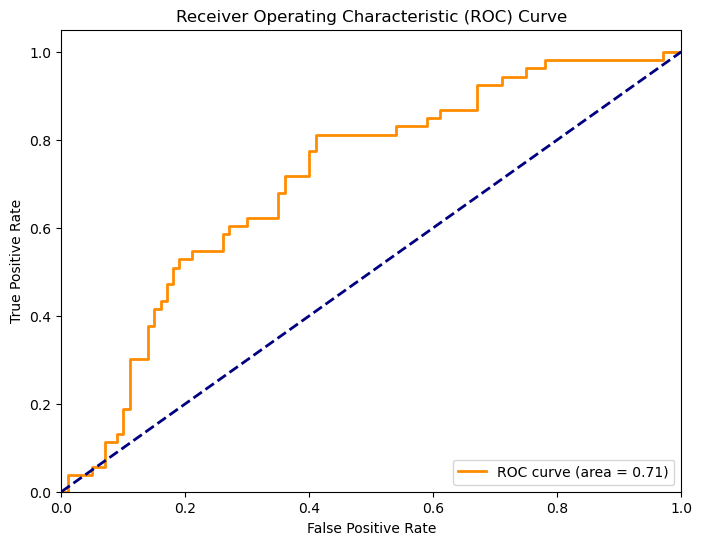

SVC Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.52        54

    accuracy                           0.35       154
   macro avg       0.18      0.50      0.26       154
weighted avg       0.12      0.35      0.18       154



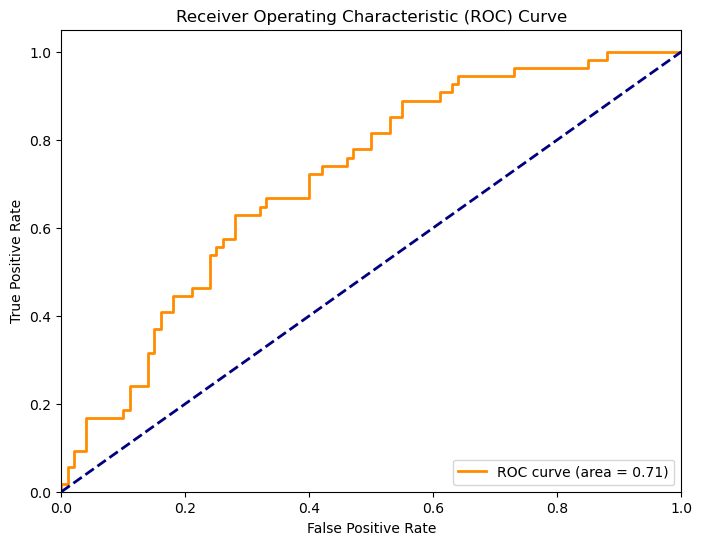

In [10]:
# Output
report_val = classification_report(y_val, y_val_pred_svc, output_dict=True)
auc_val = roc_auc_score(y_val, best_svc_pipe.decision_function(X_val_transformed))
print("SVC Validation Classification Report:")
print(classification_report(y_val, y_val_pred_svc))
get_roc_auc(y_val, best_svc_pipe.decision_function(X_val_transformed))


report_test = classification_report(y_test, y_test_pred_svc, output_dict=True)
auc_test = roc_auc_score(y_test, best_svc_pipe.decision_function(X_test_transformed))
print("SVC Test Classification Report:")
print(classification_report(y_test, y_test_pred_svc))
get_roc_auc(y_test, best_svc_pipe.decision_function(X_test_transformed))

results.append({
    "model": "SVC",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### K-NN

In [11]:
# Hyper parameter tuning for K-NN
def obj_knn(trial):
    # Hyperparameter tuning suggestions for K-NN fields
    max_k = min(56, len(X_train_transformed) // 10)
    n_neighbors = trial.suggest_int("n_neighbors", 4, max_k, step=1)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski", "chebyshev", "cosine"])
    p = trial.suggest_int("p", 1, 5) if metric == "minkowski" else None

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        metric=metric,
        p=p
    )
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    # Get f1_score
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Use Optuna to optimize the KNN model
study_knn = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_knn.optimize(obj_knn, n_trials=100)

print(f"Best hyperparameters for K-NN: {study_knn.best_params}")
print(f"Best f1_score for K-NN: {study_knn.best_value}")

# Train KNN using best params 
best_knn = KNeighborsClassifier(
    **study_knn.best_params,
)

best_knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_knn)
])

best_knn_pipe.fit(X_train_transformed, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_knn = best_knn_pipe.predict(X_val_transformed)
y_test_pred_knn = best_knn_pipe.predict(X_test_transformed)

Best hyperparameters for K-NN: {'n_neighbors': 31, 'weights': 'uniform', 'metric': 'cosine'}
Best f1_score for K-NN: 0.7378740879662866


knn Validation Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.99      0.80       100
           1       0.83      0.09      0.17        53

    accuracy                           0.68       153
   macro avg       0.75      0.54      0.49       153
weighted avg       0.73      0.68      0.58       153



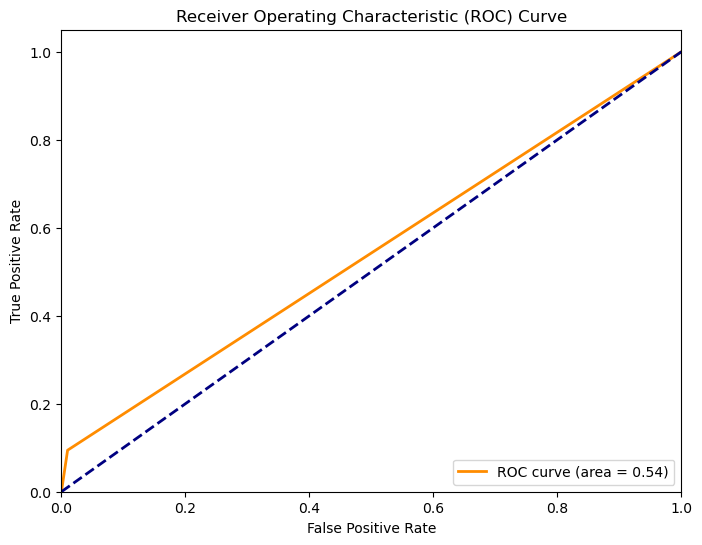

knn Test Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       100
           1       0.67      0.07      0.13        54

    accuracy                           0.66       154
   macro avg       0.66      0.53      0.46       154
weighted avg       0.66      0.66      0.56       154



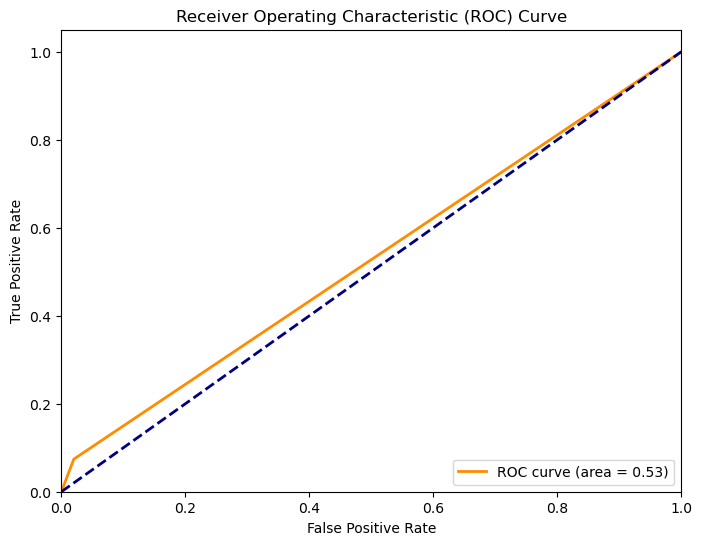

In [12]:
# Output
report_val = classification_report(y_val, y_val_pred_knn, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_pred_knn)
print("knn Validation Classification Report:")
print(classification_report(y_val, y_val_pred_knn))
get_roc_auc(y_val, y_val_pred_knn)


report_test = classification_report(y_test, y_test_pred_knn, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_pred_knn)
print("knn Test Classification Report:")
print(classification_report(y_test, y_test_pred_knn))
get_roc_auc(y_test, y_test_pred_knn)

results.append({
    "model": "knn",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### MLP

In [13]:
# Hyper parameter tuning for MLP
def create_mlp_model(params):
    """Create MLPClassifier with solver-specific parameters"""
    base_params = {
        'hidden_layer_sizes': params['hidden_layer_sizes'],
        'activation': params['activation'],
        'solver': params['solver'],
        'alpha': params['alpha'],
        'batch_size': params['batch_size'],
        'learning_rate_init': params['learning_rate_init'],
        'max_iter': params['max_iter'],
        'tol': params['tol'],
        'early_stopping': True,
        'validation_fraction': 0.1,
        'n_iter_no_change': 20,
        'random_state': 42
    }
    
    if params['solver'] == 'adam':
        base_params.update({
            'learning_rate': 'constant',
            'beta_1': params.get('beta_1', 0.9),
            'beta_2': params.get('beta_2', 0.999)
        })
    else:  # sgd
        base_params.update({
            'learning_rate': params.get('learning_rate', 'constant'),
            'momentum': params.get('momentum', 0.9),
            'nesterovs_momentum': params.get('nesterovs_momentum', False)
        })
    
    return MLPClassifier(**base_params)

def obj_MLP(trial):
    # Hyperparameter tuning suggestions for MLP fields
    hidden_layer_sizes = trial.suggest_categorical(
        "hidden_layer_sizes",
        [(64,), (128,), (256,),
         (64,64), (128,64), (128,128),
         (256,128), (256,256)]
    )
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "logistic"])
    solver = trial.suggest_categorical("solver", ["adam", "sgd"])
    alpha = trial.suggest_float("alpha", 1e-6, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-1, log=True)

    # learning_rate depends on solver
    if solver == "sgd":
        learning_rate = trial.suggest_categorical("learning_rate", ["constant", "invscaling", "adaptive"])
        momentum = trial.suggest_float("momentum", 0.49, 0.99)
        nesterovs_momentum = trial.suggest_categorical("nesterovs_momentum", [True, False])
    else:
        learning_rate = "constant"
        momentum = 0.9
        nesterovs_momentum = False
        beta_1 = trial.suggest_float("beta_1", 0.8, 0.99)
        beta_2 = trial.suggest_float("beta_2", 0.9, 0.999)

    max_iter = trial.suggest_int("max_iter", 500, 2000)
    tol = trial.suggest_float("tol", 1e-5, 1e-3, log=True)

    model = create_mlp_model({
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation': activation,
        'solver': solver,
        'alpha': alpha,
        'batch_size': batch_size,
        'learning_rate_init': learning_rate_init,
        'max_iter': max_iter,
        'tol': tol,
        'learning_rate': learning_rate,
        'momentum': momentum if solver == 'sgd' else None,
        'nesterovs_momentum': nesterovs_momentum if solver == 'sgd' else None,
        'beta_1': beta_1 if solver == 'adam' else None,
        'beta_2': beta_2 if solver == 'adam' else None
    })

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    # Get f1_score
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Use Optuna to optimize the MLP model
study_MLP = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_MLP.optimize(obj_MLP, n_trials=100)

print(f"Best hyperparameters for MLP: {study_MLP.best_params}")
print(f"Best f1_score for MLP: {study_MLP.best_value}")

# Train MLP using best params 
best_MLP = create_mlp_model(study_MLP.best_params)

best_MLP_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_MLP)
])

best_MLP_pipe.fit(X_train_transformed, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_MLP = best_MLP_pipe.predict(X_val_transformed)
y_test_pred_MLP = best_MLP_pipe.predict(X_test_transformed)

Best hyperparameters for MLP: {'hidden_layer_sizes': (64,), 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.00011682868719968657, 'batch_size': 256, 'learning_rate_init': 0.07123290096455366, 'beta_1': 0.8393780111883882, 'beta_2': 0.9885849655887533, 'max_iter': 619, 'tol': 0.00040341201842777647}
Best f1_score for MLP: 0.7556126363550348


MLP Validation Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.87      0.75       100
           1       0.41      0.17      0.24        53

    accuracy                           0.63       153
   macro avg       0.54      0.52      0.50       153
weighted avg       0.58      0.63      0.58       153



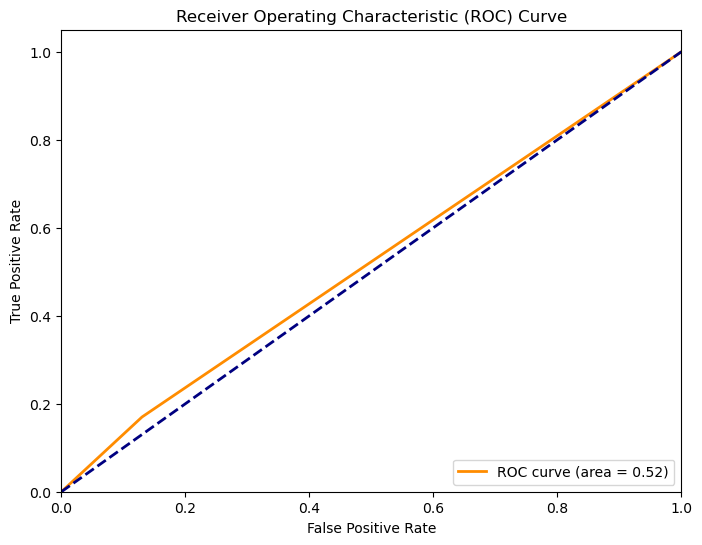

MLP Test Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.95      0.81       100
           1       0.72      0.24      0.36        54

    accuracy                           0.70       154
   macro avg       0.71      0.60      0.58       154
weighted avg       0.71      0.70      0.65       154



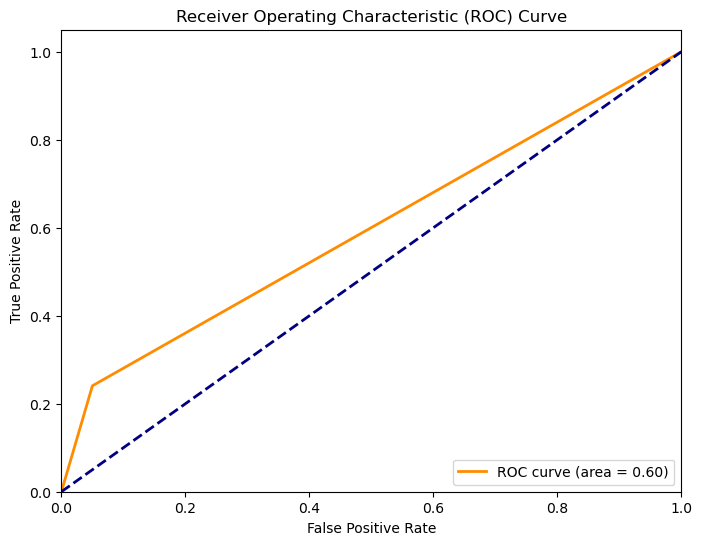

In [14]:
# Output
report_val = classification_report(y_val, y_val_pred_MLP, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_pred_MLP)
print("MLP Validation Classification Report:")
print(classification_report(y_val, y_val_pred_MLP))
get_roc_auc(y_val, y_val_pred_MLP)


report_test = classification_report(y_test, y_test_pred_MLP, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_pred_MLP)
print("MLP Test Classification Report:")
print(classification_report(y_test, y_test_pred_MLP))
get_roc_auc(y_test, y_test_pred_MLP)

results.append({
    "model": "MLP",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### Logistic Regression

In [15]:
# Hyper parameter tuning for logistic_regression
def obj_logistic_regression(trial):
    # Hyperparameter tuning suggestions for logistic_regression fields
    penalty = trial.suggest_categorical("penalty", ["l2", "elasticnet"])
    if penalty == "elasticnet":
        solver = "saga"
        l1_ratio = trial.suggest_float("l1_ratio", 0.05, 0.95)
    else: 
        solver = trial.suggest_categorical("solver", ["lbfgs", "saga"])
        l1_ratio = None

    C = trial.suggest_float("C", 1e-3, 1e3)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    max_iter = trial.suggest_int("max_iter", 200, 6000, step=200)
    tol = trial.suggest_float("tol", 1e-6, 1e-3, log=True)

    model_params = {
        'penalty': penalty,
        'solver': solver,
        'C': C,
        'class_weight': class_weight,
        'tol': tol,
        'max_iter': max_iter,
        'random_state': 42,
        'n_jobs': None
    }
    
    # Only add l1_ratio for elasticnet
    if penalty == "elasticnet":
        model_params['l1_ratio'] = l1_ratio
    
    model = LogisticRegression(**model_params)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    # Get f1_score
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Use Optuna to optimize the logistic_regression model
study_logistic_regression = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_logistic_regression.optimize(obj_logistic_regression, n_trials=100)

print(f"Best hyperparameters for logistic_regression: {study_logistic_regression.best_params}")
print(f"Best f1_score for logistic_regression: {study_logistic_regression.best_value}")

def solve_invalid_hyperparameters(params):
    params = params.copy()
    if params.get('solver') == "lbfgs":
        params['penalty'] = 'l2'
    
    return params

# Train logistic_regression using best params 
best_logistic_regression = LogisticRegression(
    **solve_invalid_hyperparameters(study_logistic_regression.best_params),
    random_state=42
)

best_logistic_regression_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_logistic_regression)
])

best_logistic_regression_pipe.fit(X_train_transformed, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_logistic_regression = best_logistic_regression_pipe.predict(X_val_transformed)
y_test_pred_logistic_regression = best_logistic_regression_pipe.predict(X_test_transformed)

Best hyperparameters for logistic_regression: {'penalty': 'l2', 'solver': 'saga', 'C': 436.7302724192662, 'class_weight': 'balanced', 'max_iter': 4400, 'tol': 0.0006641485241584163}
Best f1_score for logistic_regression: 0.7285163872362974


logistic_regression Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.34      0.98      0.51        53

    accuracy                           0.34       153
   macro avg       0.17      0.49      0.25       153
weighted avg       0.12      0.34      0.18       153



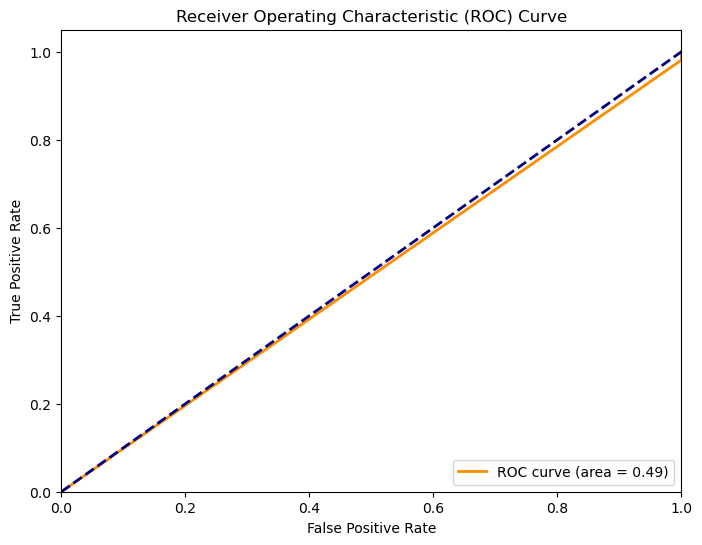

logistic_regression Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.34      0.96      0.50        54

    accuracy                           0.34       154
   macro avg       0.17      0.48      0.25       154
weighted avg       0.12      0.34      0.18       154



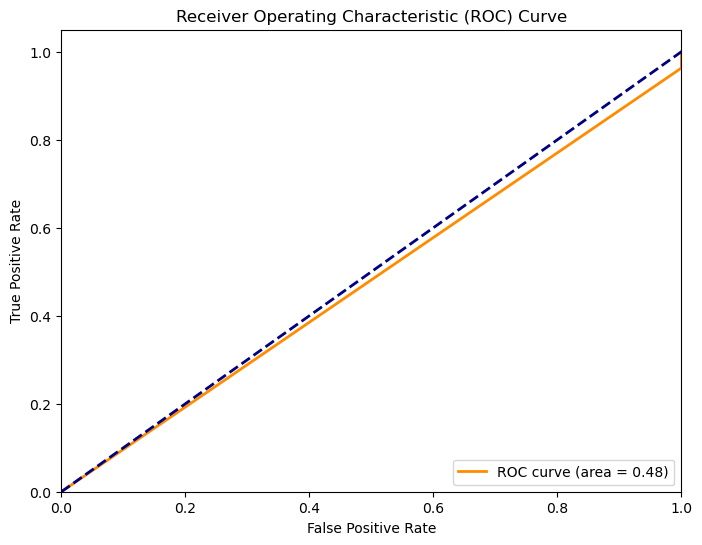

In [16]:
# Output
report_val = classification_report(y_val, y_val_pred_logistic_regression, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_pred_logistic_regression)
print("logistic_regression Validation Classification Report:")
print(classification_report(y_val, y_val_pred_logistic_regression))
get_roc_auc(y_val, y_val_pred_logistic_regression)


report_test = classification_report(y_test, y_test_pred_logistic_regression, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_pred_logistic_regression)
print("logistic_regression Test Classification Report:")
print(classification_report(y_test, y_test_pred_logistic_regression))
get_roc_auc(y_test, y_test_pred_logistic_regression)

results.append({
    "model": "logistic_regression",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### GaussianNB

In [17]:
# Hyper parameter tuning for gaussian_nb
def obj_gaussian_nb(trial):
    # Hyperparameter tuning suggestions for gaussian_nb fields
    var_smoothing = trial.suggest_float("var_smoothing", 1e-14, 1e-4, log=True)

    # Define the model
    model = GaussianNB(
        var_smoothing=var_smoothing
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    # Get f1_score
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Use Optuna to optimize the gaussian_nb model
study_gaussian_nb = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_gaussian_nb.optimize(obj_gaussian_nb, n_trials=100)

print(f"Best hyperparameters for gaussian_nb: {study_gaussian_nb.best_params}")
print(f"Best f1_score for gaussian_nb: {study_gaussian_nb.best_value}")

# Train gaussian_nb using best params 
best_gaussian_nb = GaussianNB(
    **study_gaussian_nb.best_params,
)
best_gaussian_nb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_gaussian_nb)
])

best_gaussian_nb_pipe.fit(X_train_transformed, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_gaussian_nb = best_gaussian_nb_pipe.predict(X_val_transformed)
y_test_pred_gaussian_nb = best_gaussian_nb_pipe.predict(X_test_transformed)

Best hyperparameters for gaussian_nb: {'var_smoothing': 7.1283917562507485e-09}
Best f1_score for gaussian_nb: 0.7279307353596451


gaussian_nb Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.51        53

    accuracy                           0.35       153
   macro avg       0.17      0.50      0.26       153
weighted avg       0.12      0.35      0.18       153



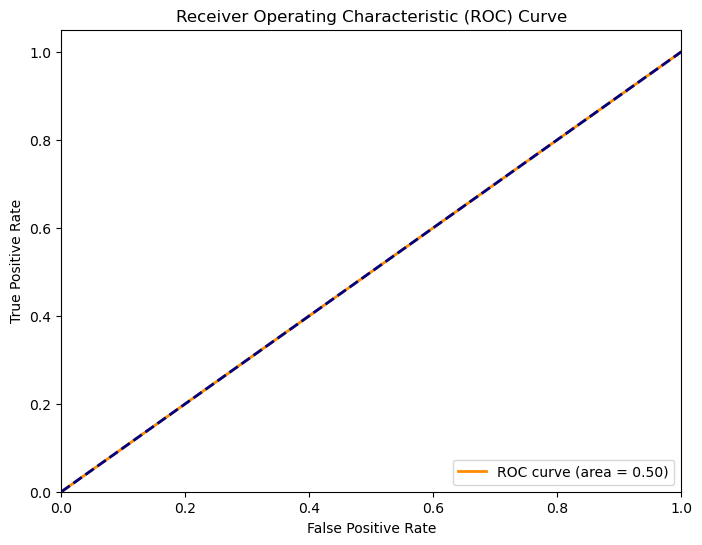

gaussian_nb Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.52        54

    accuracy                           0.35       154
   macro avg       0.18      0.50      0.26       154
weighted avg       0.12      0.35      0.18       154



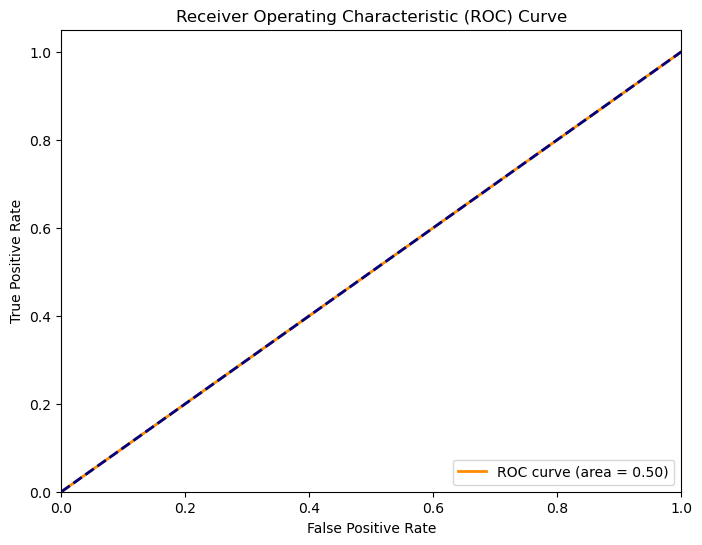

In [18]:
# Output
report_val = classification_report(y_val, y_val_pred_gaussian_nb, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_pred_gaussian_nb)
print("gaussian_nb Validation Classification Report:")
print(classification_report(y_val, y_val_pred_gaussian_nb))
get_roc_auc(y_val, y_val_pred_gaussian_nb)


report_test = classification_report(y_test, y_test_pred_gaussian_nb, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_pred_gaussian_nb)
print("gaussian_nb Test Classification Report:")
print(classification_report(y_test, y_test_pred_gaussian_nb))
get_roc_auc(y_test, y_test_pred_gaussian_nb)

results.append({
    "model": "gaussian_nb",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### XGBoost

In [19]:
# Hyper parameter tuning for xg_boost
def obj_xg_boost(trial):
    # Hyperparameter tuning suggestions for xg_boost fields
    params = {
        "booster": trial.suggest_categorical("booster", ["gbtree", "dart"]),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "logloss"
    }
    
    # Define the model
    model = xgb.XGBClassifier(**params)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    # Get f1_score
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Use Optuna to optimize the xg_boost model
study_xg_boost = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_xg_boost.optimize(obj_xg_boost, n_trials=100)

print(f"Best hyperparameters for xg_boost: {study_xg_boost.best_params}")
print(f"Best f1_score for xg_boost: {study_xg_boost.best_value}")

# Train xg_boost using best params 
best_xg_boost = xgb.XGBClassifier(
    **study_xg_boost.best_params,
    random_state=42,
    n_jobs=-1
)
best_xg_boost_pipe = Pipeline([
    ("clf", best_xg_boost)
])

best_xg_boost_pipe.fit(X_train_transformed, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_xg_boost = best_xg_boost_pipe.predict(X_val_transformed)
y_test_pred_xg_boost = best_xg_boost_pipe.predict(X_test_transformed)

Best hyperparameters for xg_boost: {'booster': 'gbtree', 'reg_lambda': 1.0740620714019016e-06, 'reg_alpha': 1.0290590864488345e-05, 'max_depth': 6, 'learning_rate': 0.03006460085394568, 'gamma': 6.764866967812444, 'grow_policy': 'depthwise', 'subsample': 0.681327783431327, 'colsample_bytree': 0.9404197419391911, 'n_estimators': 489}
Best f1_score for xg_boost: 0.7518516406909261


xg_boost Validation Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       100
           1       0.71      0.68      0.69        53

    accuracy                           0.79       153
   macro avg       0.77      0.76      0.77       153
weighted avg       0.79      0.79      0.79       153



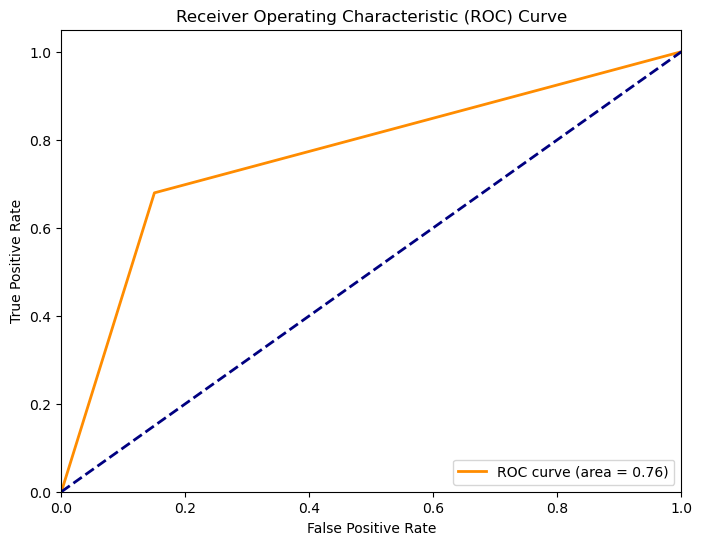

xg_boost Test Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       100
           1       0.62      0.52      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154



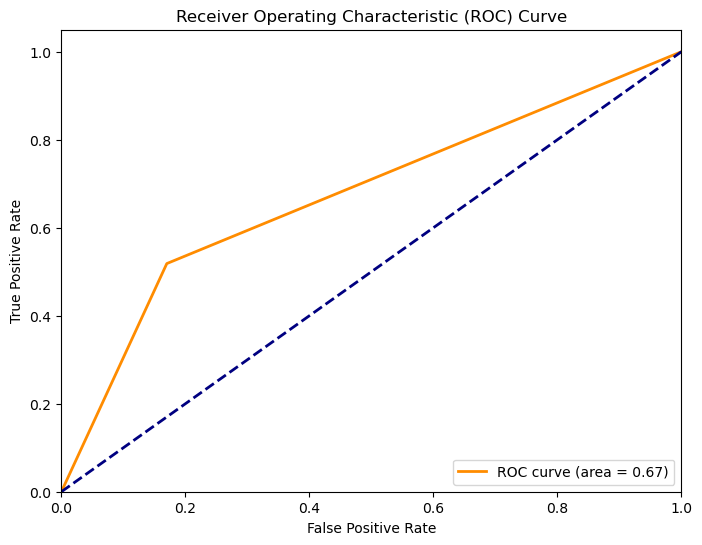

In [20]:
# Output
report_val = classification_report(y_val, y_val_pred_xg_boost, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_pred_xg_boost)
print("xg_boost Validation Classification Report:")
print(classification_report(y_val, y_val_pred_xg_boost))
get_roc_auc(y_val, y_val_pred_xg_boost)


report_test = classification_report(y_test, y_test_pred_xg_boost, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_pred_xg_boost)
print("xg_boost Test Classification Report:")
print(classification_report(y_test, y_test_pred_xg_boost))
get_roc_auc(y_test, y_test_pred_xg_boost)

results.append({
    "model": "xg_boost",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### DeepMLP

In [ ]:
# Hyper parameter tuning for deep_mlp

# Build function
def make_mlp(
    n_features: int,
    hidden1: int = 128,
    hidden2: int = 64,
    dropout: float = 0.3,
    activation: str = "relu",
    l2_reg: float = 1e-4,
    optimizer_name: str = "adam",
    lr: float = 1e-3,
    momentum: float = 0.9,
):
    inp = keras.Input(shape=(n_features,))
    x = layers.BatchNormalization()(inp)

    x = layers.Dense(hidden1, activation=activation, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout)(x)

    if hidden2 and hidden2 > 0:
        x = layers.Dense(hidden2, activation=activation, kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = layers.Dropout(dropout)(x)

    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)

    if optimizer_name == "adam":
        opt = optimizers.Adam(learning_rate=lr)
    else:
        opt = optimizers.SGD(learning_rate=lr, momentum=momentum, nesterov=True)

    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["AUC"])
    return model

def obj_deep_mlp(trial):
    # Hyperparameter tuning
    hidden1 = trial.suggest_categorical("hidden1", [64, 128, 256, 384])
    hidden2 = trial.suggest_categorical("hidden2", [0, 64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.6)
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "elu"])
    l2_reg = trial.suggest_float("l2_reg", 1e-6, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer_name", ["adam", "sgd"])
    lr = trial.suggest_float("lr", 1e-4, 5e-2, log=True)
    momentum = trial.suggest_float("momentum", 0.8, 0.99) if optimizer_name == "sgd" else 0.9
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    epochs = trial.suggest_int("epochs", 30, 150)
    
    # SciKeras classifier
    model = KerasClassifier(
        model=make_mlp,
        model__n_features=X_train_transformed.shape[1],
        model__hidden1=hidden1,
        model__hidden2=hidden2,
        model__dropout=dropout,
        model__activation=activation,
        model__l2_reg=l2_reg,
        model__optimizer_name=optimizer_name,
        model__lr=lr,
        model__momentum=momentum,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        validation_split=0.1,
        callbacks=[
            callbacks.EarlyStopping(
                monitor="val_auc", 
                mode="max",
                patience=20, 
                restore_best_weights=True
            ),
            TFKerasPruningCallback(trial, monitor="val_auc"),
        ],
    )
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])
    
    # Get f1_score
    f1_score = cross_val_score(
        pipe,
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()
    return f1_score

# Use Optuna to optimize the deep_mlp model
study_deep_mlp = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_deep_mlp.optimize(obj_deep_mlp, n_trials=100)

print(f"Best hyperparameters for deep_mlp: {study_deep_mlp.best_params}")
print(f"Best f1_score for deep_mlp: {study_deep_mlp.best_value}")

best_params = study_deep_mlp.best_params.copy()

# Create final model with proper callbacks (no pruning)
best_deep_mlp = KerasClassifier(
    model=make_mlp,
    model__n_features=X_train_transformed.shape[1],
    model__hidden1=best_params['hidden1'],
    model__hidden2=best_params['hidden2'],
    model__dropout=best_params['dropout'],
    model__activation=best_params['activation'],
    model__l2_reg=best_params['l2_reg'],
    model__optimizer_name=best_params['optimizer_name'],
    model__lr=best_params['lr'],
    model__momentum=best_params.get('momentum', 0.9),
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=0,
    validation_split=0.1,
    callbacks=[
        callbacks.EarlyStopping(
            monitor="val_auc", 
            mode="max",
            patience=20, 
            restore_best_weights=True
        )
    ],
)

best_deep_mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_deep_mlp)
])

best_deep_mlp_pipe.fit(X_train_transformed, y_train)

# Evaluate deep_mlp on val and test data
y_val_pred_deep_mlp = best_deep_mlp_pipe.predict(X_val_transformed)
y_test_pred_deep_mlp = best_deep_mlp_pipe.predict(X_test_transformed)

deep_mlp Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.51        53

    accuracy                           0.35       153
   macro avg       0.17      0.50      0.26       153
weighted avg       0.12      0.35      0.18       153



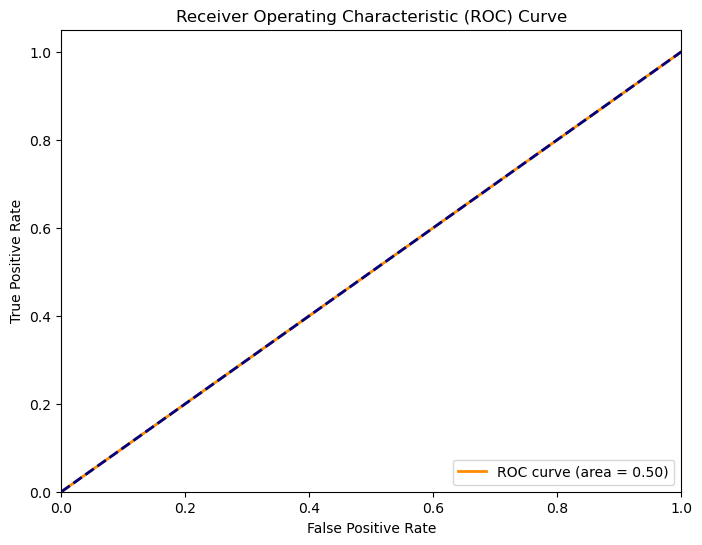

deep_mlp Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.52        54

    accuracy                           0.35       154
   macro avg       0.18      0.50      0.26       154
weighted avg       0.12      0.35      0.18       154



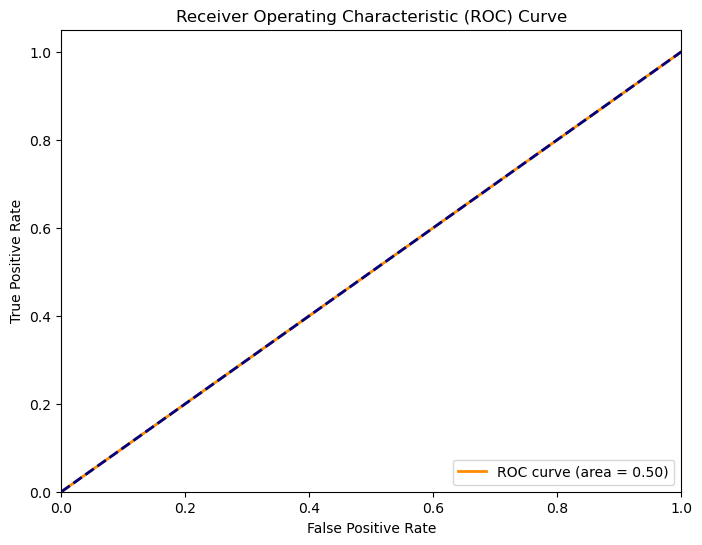

In [ ]:
# Output
report_val = classification_report(y_val, y_val_pred_deep_mlp, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_pred_deep_mlp)
print("deep_mlp Validation Classification Report:")
print(classification_report(y_val, y_val_pred_deep_mlp))
get_roc_auc(y_val, y_val_pred_deep_mlp)


report_test = classification_report(y_test, y_test_pred_deep_mlp, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_pred_deep_mlp)
print("deep_mlp Test Classification Report:")
print(classification_report(y_test, y_test_pred_deep_mlp))
get_roc_auc(y_test, y_test_pred_deep_mlp)

results.append({
    "model": "deep_mlp",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### Decision Tree

In [ ]:
# Hyper parameter tuning for decision_tree
def obj_decision_tree(trial):
    # Hyperparameter tuning suggestions for decision_tree fields
    max_depth = trial.suggest_int("max_depth", 2, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

    # define te model
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    # Get f1_score
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Use Optuna to optimize the decision_tree model
study_decision_tree = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_decision_tree.optimize(obj_decision_tree, n_trials=100)

print(f"Best hyperparameters for decision_tree: {study_decision_tree.best_params}")
print(f"Best f1_score for decision_tree: {study_decision_tree.best_value}")

# Train decision_tree using best params 
best_decision_tree = DecisionTreeClassifier(
    **study_decision_tree.best_params,
    random_state=42
)
best_decision_tree_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_decision_tree)
])

best_decision_tree_pipe.fit(X_train_transformed, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_decision_tree = best_decision_tree_pipe.predict(X_val_transformed)
y_test_pred_decision_tree = best_decision_tree_pipe.predict(X_test_transformed)

Best hyperparameters for decision_tree: {'max_depth': 49, 'min_samples_split': 2, 'min_samples_leaf': 20, 'criterion': 'entropy'}
Best f1_score for decision_tree: 0.7167811174805608


decision_tree Validation Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       100
           1       0.71      0.57      0.63        53

    accuracy                           0.77       153
   macro avg       0.75      0.72      0.73       153
weighted avg       0.77      0.77      0.76       153



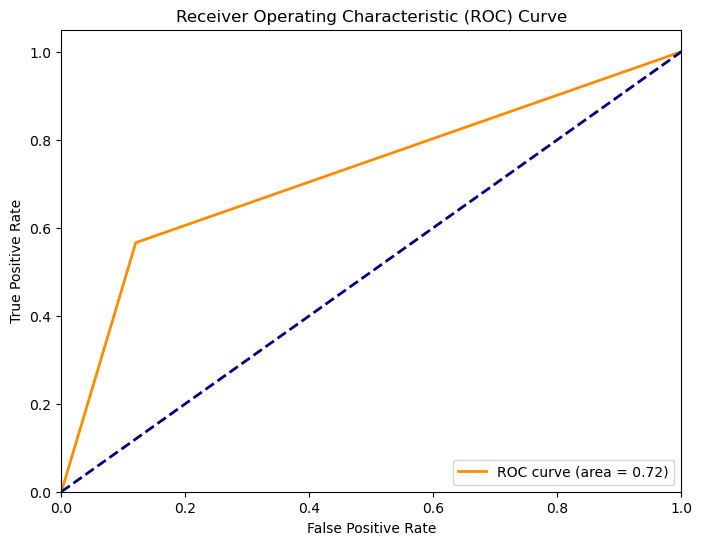

decision_tree Test Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.87      0.79       100
           1       0.61      0.37      0.46        54

    accuracy                           0.69       154
   macro avg       0.66      0.62      0.62       154
weighted avg       0.68      0.69      0.67       154



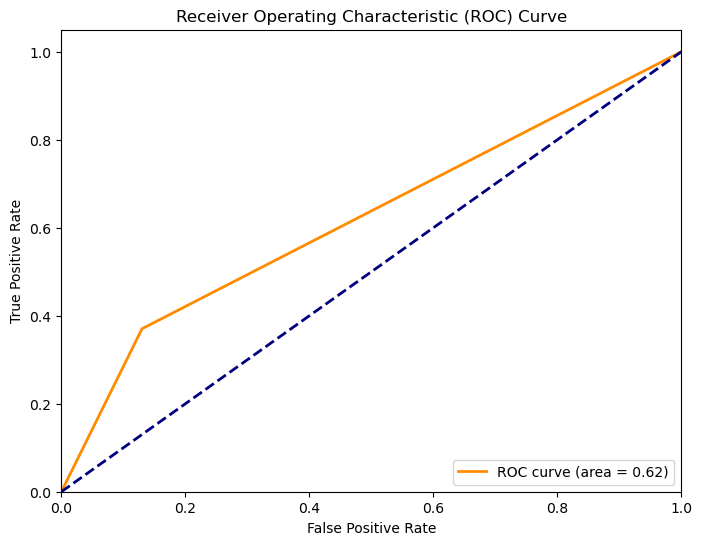

In [ ]:
# Output
report_val = classification_report(y_val, y_val_pred_decision_tree, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_pred_decision_tree)
print("decision_tree Validation Classification Report:")
print(classification_report(y_val, y_val_pred_decision_tree))
get_roc_auc(y_val, y_val_pred_decision_tree)


report_test = classification_report(y_test, y_test_pred_decision_tree, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_pred_decision_tree)
print("decision_tree Test Classification Report:")
print(classification_report(y_test, y_test_pred_decision_tree))
get_roc_auc(y_test, y_test_pred_decision_tree)

results.append({
    "model": "decision_tree",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### RandomForest

In [ ]:
# Hyper parameter tuning for random_forest
def obj_random_forest(trial):
    # Hyperparameter tuning suggestions for random_forest fields
    n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=100)
    max_depth = trial.suggest_int("max_depth", 3, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    # Defin the model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    # Get f1_score
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Use Optuna to optimize the random_forest model
study_random_forest = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_random_forest.optimize(obj_random_forest, n_trials=100)

print(f"Best hyperparameters for random_forest: {study_random_forest.best_params}")
print(f"Best f1_score for random_forest: {study_random_forest.best_value}")

# Train random_forest using best params 
best_random_forest = RandomForestClassifier(
    **study_random_forest.best_params,
    random_state=42
)
best_random_forest_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_random_forest)
])

best_random_forest_pipe.fit(X_train_transformed, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_random_forest = best_random_forest_pipe.predict(X_val_transformed)
y_test_pred_random_forest = best_random_forest_pipe.predict(X_test_transformed)

Best hyperparameters for random_forest: {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None}
Best f1_score for random_forest: 0.7434351985565428


random_forest Validation Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.72      0.77       100
           1       0.57      0.70      0.63        53

    accuracy                           0.71       153
   macro avg       0.69      0.71      0.70       153
weighted avg       0.73      0.71      0.72       153



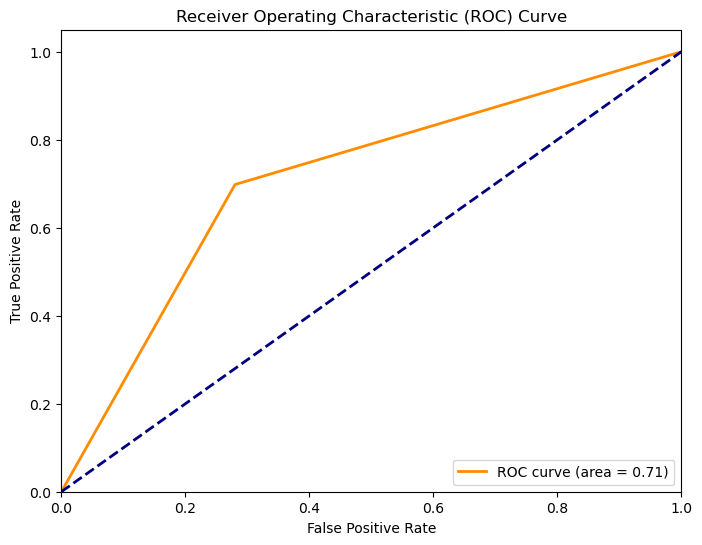

random_forest Test Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.59      0.61      0.60        54

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154



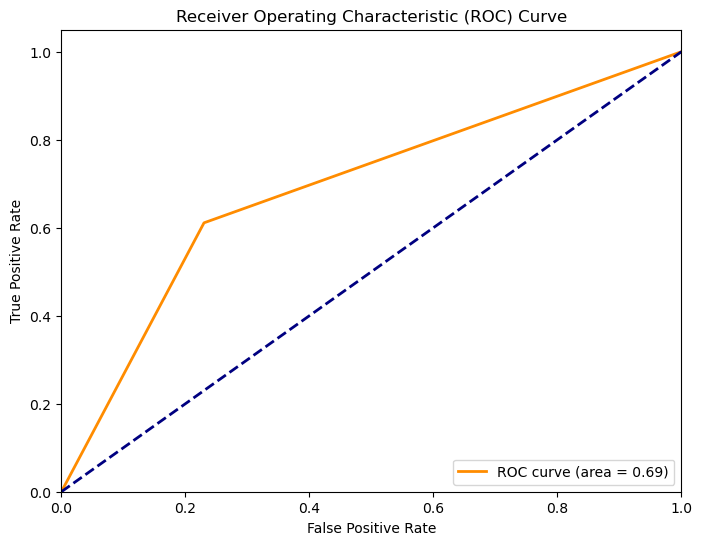

In [ ]:
# Output
report_val = classification_report(y_val, y_val_pred_random_forest, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_pred_random_forest)
print("random_forest Validation Classification Report:")
print(classification_report(y_val, y_val_pred_random_forest))
get_roc_auc(y_val, y_val_pred_random_forest)


report_test = classification_report(y_test, y_test_pred_random_forest, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_pred_random_forest)
print("random_forest Test Classification Report:")
print(classification_report(y_test, y_test_pred_random_forest))
get_roc_auc(y_test, y_test_pred_random_forest)

results.append({
    "model": "random_forest",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### GradientBoosting

In [ ]:
# Hyper parameter tuning for gradient_boosting
def obj_gradient_boosting(trial):
    # Hyperparameter tuning suggestions for gradient_boosting fields
    n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=100)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.2, log=True)
    max_depth = trial.suggest_int("max_depth", 2, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Define the model
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        max_features=max_features,
        random_state=42
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    # Get f1_score
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Use Optuna to optimize the gradient_boosting model
study_gradient_boosting = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_gradient_boosting.optimize(obj_gradient_boosting, n_trials=100)

print(f"Best hyperparameters for gradient_boosting: {study_gradient_boosting.best_params}")
print(f"Best f1_score for gradient_boosting: {study_gradient_boosting.best_value}")

# Train gradient_boosting using best params 
best_gradient_boosting = GradientBoostingClassifier(
    **study_gradient_boosting.best_params,
    random_state=42
)
best_gradient_boosting_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_gradient_boosting)
])

best_gradient_boosting_pipe.fit(X_train_transformed, y_train)

# Evaluate LinearSVC on val and test data
y_val_pred_gradient_boosting = best_gradient_boosting_pipe.predict(X_val_transformed)
y_test_pred_gradient_boosting = best_gradient_boosting_pipe.predict(X_test_transformed)

Best hyperparameters for gradient_boosting: {'n_estimators': 900, 'learning_rate': 0.005995176311331362, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 2, 'subsample': 0.9882044770153702, 'max_features': 'sqrt'}
Best f1_score for gradient_boosting: 0.7452587748327704


gradient_boosting Validation Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.53      0.65       100
           1       0.47      0.79      0.59        53

    accuracy                           0.62       153
   macro avg       0.65      0.66      0.62       153
weighted avg       0.70      0.62      0.63       153



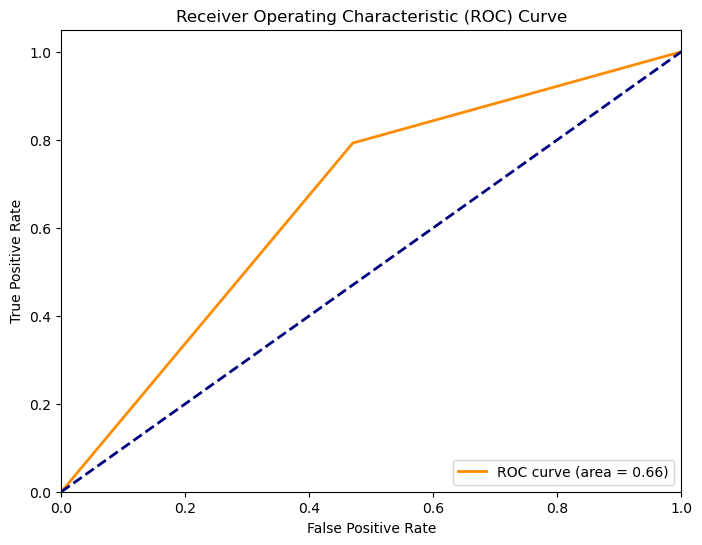

gradient_boosting Test Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.62      0.70       100
           1       0.51      0.72      0.60        54

    accuracy                           0.66       154
   macro avg       0.66      0.67      0.65       154
weighted avg       0.70      0.66      0.66       154



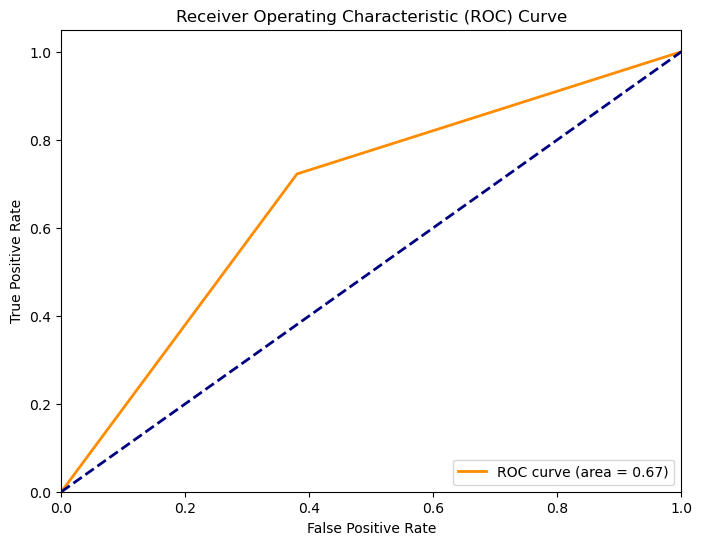

In [ ]:
# Output
report_val = classification_report(y_val, y_val_pred_gradient_boosting, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_pred_gradient_boosting)
print("gradient_boosting Validation Classification Report:")
print(classification_report(y_val, y_val_pred_gradient_boosting))
get_roc_auc(y_val, y_val_pred_gradient_boosting)


report_test = classification_report(y_test, y_test_pred_gradient_boosting, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_pred_gradient_boosting)
print("gradient_boosting Test Classification Report:")
print(classification_report(y_test, y_test_pred_gradient_boosting))
get_roc_auc(y_test, y_test_pred_gradient_boosting)

results.append({
    "model": "gradient_boosting",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

## Ensemble Methods

### Voting

In [ ]:
# Tree + Margin
def obj_tree_margin(trial):
    w1 = trial.suggest_int("w_xgb", 1, 5)
    w2 = trial.suggest_int("w_rf", 1, 5)
    w3 = trial.suggest_int("w_svc", 1, 5)
    
    # Use models directly
    svc_with_proba = clone(best_svc)
    svc_with_proba.set_params(probability=True)
    
    model = VotingClassifier(
        estimators=[
            ("xgb", clone(best_xg_boost)),
            ("rf", clone(best_random_forest)),
            ("svc", Pipeline([("scaler", StandardScaler()), ("clf", svc_with_proba)])),
        ],
        voting="soft",
        weights=[w1, w2, w3],
        n_jobs=-1
    )
    
    f1_score = cross_val_score(
        model,
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()
    return f1_score

# Run optimization
study_tree_margin = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_tree_margin.optimize(obj_tree_margin, n_trials=100)

print(f"Best hyperparameters for tree_margin: {study_tree_margin.best_params}")
print(f"Best f1_score for tree_margin: {study_tree_margin.best_value}")

best_params = study_tree_margin.best_params

svc_with_proba = clone(best_svc)
svc_with_proba.set_params(probability=True)

# Train tree_margin using best params 
best_tree_margin = VotingClassifier(
    estimators=[
        ("xgb", clone(best_xg_boost)),
        ("rf", clone(best_random_forest)),
        ("svc", Pipeline([("scaler", StandardScaler()), ("clf", clone(svc_with_proba))])),
    ],
    voting="soft",
    weights=[best_params["w_xgb"], best_params["w_rf"], best_params["w_svc"]],
    n_jobs=-1
)

best_tree_margin.fit(X_train_transformed, y_train)

# Evaluate tree_margin on val and test data
y_val_pred_tree_margin = best_tree_margin.predict(X_val_transformed)
y_val_proba_tree_margin = best_tree_margin.predict_proba(X_val_transformed)[:, 1]

y_test_pred_tree_margin = best_tree_margin.predict(X_test_transformed)
y_test_proba_tree_margin = best_tree_margin.predict_proba(X_test_transformed)[:, 1]

Best hyperparameters for tree_margin: {'w_xgb': 5, 'w_rf': 1, 'w_svc': 1}
Best f1_score for tree_margin: 0.7527897295176986


tree_margin Validation Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       100
           1       0.67      0.74      0.70        53

    accuracy                           0.78       153
   macro avg       0.76      0.77      0.77       153
weighted avg       0.79      0.78      0.79       153



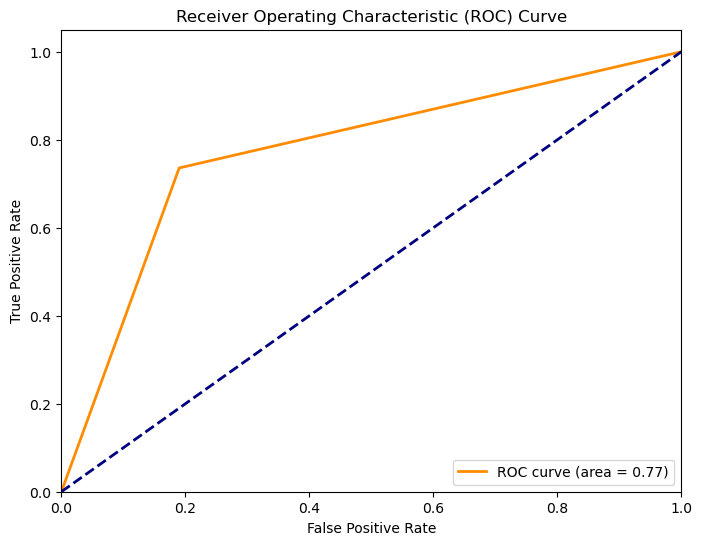

tree_margin Test Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       100
           1       0.62      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154



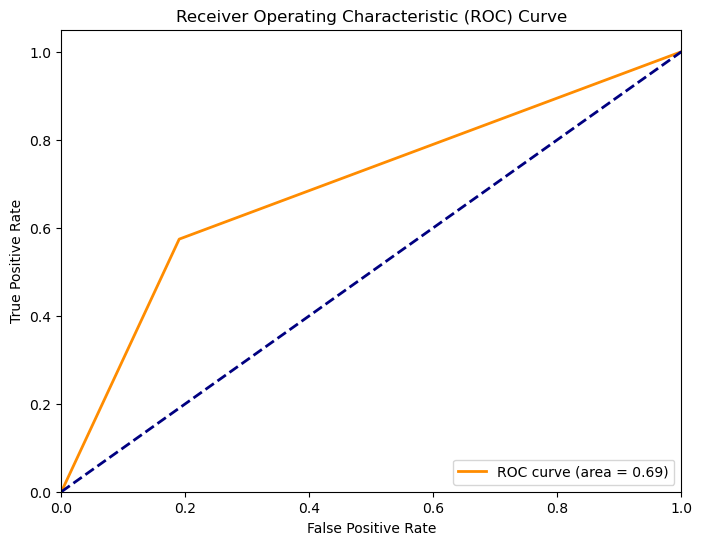

In [ ]:
# Output
report_val = classification_report(y_val, y_val_pred_tree_margin, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_proba_tree_margin)
print("tree_margin Validation Classification Report:")
print(classification_report(y_val, y_val_pred_tree_margin))
get_roc_auc(y_val, y_val_pred_tree_margin)


report_test = classification_report(y_test, y_test_pred_tree_margin, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_proba_tree_margin)
print("tree_margin Test Classification Report:")
print(classification_report(y_test, y_test_pred_tree_margin))
get_roc_auc(y_test, y_test_pred_tree_margin)

results.append({
    "model": "tree_margin",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

In [ ]:
# blend
best_gradient_boosting_clone = clone(best_gradient_boosting)
best_logistic_regression_clone = clone(best_logistic_regression)
knn_calc = CalibratedClassifierCV(clone(best_knn), cv=3)
def obj_blend(trial):
    w1 = trial.suggest_int("w_gb", 1, 5)
    w2 = trial.suggest_int("w_lg", 1, 5)
    w3 = trial.suggest_int("w_knn", 1, 5)

    # Define ensemble model
    model = VotingClassifier(
        estimators=[
            ("gb", best_gradient_boosting_clone),
            ("lg", Pipeline([("scaler", StandardScaler()),("clf",best_logistic_regression_clone)])),
            ("knn", Pipeline([("scaler", StandardScaler()),("clf",knn_calc)])),
        ],
        voting="soft",
        weights=[w1, w2, w3],
        n_jobs=-1
    )

    # Fit on training
    pipe = Pipeline([
        ("clf", model)
    ])

    # Metrics
    f1_score = cross_val_score(
        pipe, 
        X_train_transformed,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return f1_score

# Run optimization
study_blend = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study_blend.optimize(obj_blend, n_trials=100)

print(f"Best hyperparameters for blend: {study_blend.best_params}")
print(f"Best f1_score for blend: {study_blend.best_value}")

best_params = study_blend.best_params

# Train blend using best params 
best_blend = VotingClassifier(
    estimators=[
        ("gb", best_gradient_boosting_clone),
        ("lg", Pipeline([("scaler", StandardScaler()),("clf",best_logistic_regression_clone)])),
        ("knn", Pipeline([("scaler", StandardScaler()),("clf",knn_calc)])),
    ],
    voting="soft",
    weights=[best_params["w_gb"], best_params["w_lg"], best_params["w_knn"]],
    n_jobs=-1
)
best_blend.fit(X_train_transformed, y_train)

# Evaluate blend on val and test data
y_val_pred_blend = best_blend.predict(X_val_transformed)
y_val_proba_blend = best_blend.predict_proba(X_val_transformed)[:, 1]

y_test_pred_blend = best_blend.predict(X_test_transformed)
y_test_proba_blend = best_blend.predict_proba(X_test_transformed)[:, 1]

Best hyperparameters for blend: {'w_gb': 5, 'w_lg': 1, 'w_knn': 1}
Best f1_score for blend: 0.7404371809890776


blend Validation Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.51      0.63       100
           1       0.47      0.81      0.59        53

    accuracy                           0.61       153
   macro avg       0.65      0.66      0.61       153
weighted avg       0.71      0.61      0.62       153



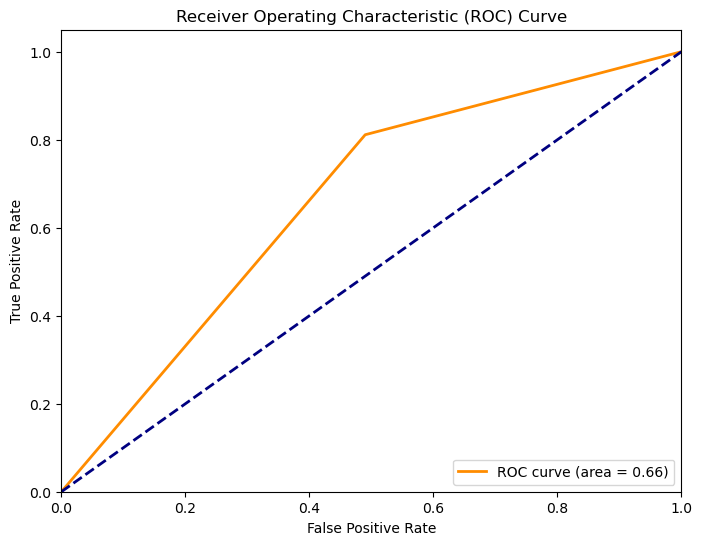

blend Test Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.58      0.68       100
           1       0.50      0.78      0.61        54

    accuracy                           0.65       154
   macro avg       0.66      0.68      0.65       154
weighted avg       0.71      0.65      0.66       154



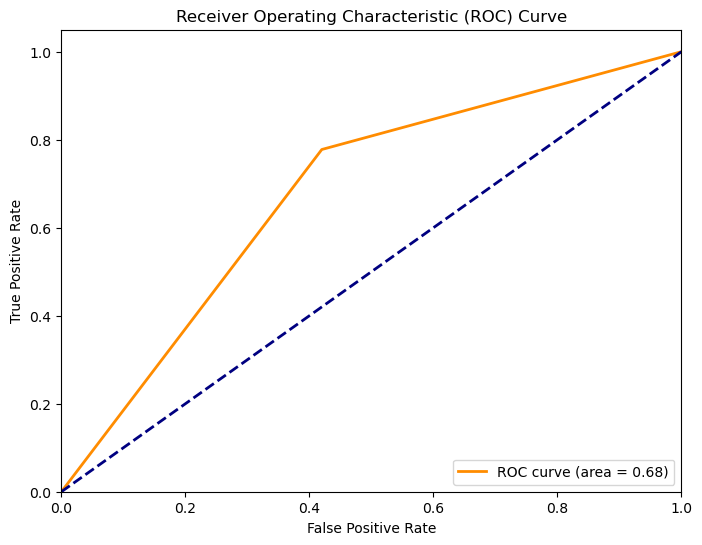

In [ ]:
# Output
report_val = classification_report(y_val, y_val_pred_blend, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_proba_blend)
print("blend Validation Classification Report:")
print(classification_report(y_val, y_val_pred_blend))
get_roc_auc(y_val, y_val_pred_blend)


report_test = classification_report(y_test, y_test_pred_blend, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_proba_blend)
print("blend Test Classification Report:")
print(classification_report(y_test, y_test_pred_blend))
get_roc_auc(y_test, y_test_pred_blend)

results.append({
    "model": "blend",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

### Stacking

In [ ]:
best_5_stack = StackingClassifier(
    estimators=[
        ("xgb", clone(best_xg_boost)),
        ("rf", clone(best_random_forest)),
        ("gb", clone(best_gradient_boosting)),
        ("lg", Pipeline([("scaler", StandardScaler()), ("clf", clone(best_linear_svc))])),
        ("deepmlp", Pipeline([("scaler", StandardScaler()), ("clf", clone(best_deep_mlp))])),
    ],
    final_estimator=clone(best_logistic_regression),
    cv=5,
    stack_method="auto", 
    passthrough=False,
    n_jobs=-1
)

# NO scaling at the top level - individual models handle their own scaling needs
best_5_stack.fit(X_train_transformed, y_train)

# Evaluate 5_stack on val and test data
y_val_pred_5_stack = best_5_stack.predict(X_val_transformed)
y_val_proba_5_stack = best_5_stack.predict_proba(X_val_transformed)[:, 1]
y_test_pred_5_stack = best_5_stack.predict(X_test_transformed)
y_test_proba_5_stack = best_5_stack.predict_proba(X_test_transformed)[:, 1]

5_stack Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.51        53

    accuracy                           0.35       153
   macro avg       0.17      0.50      0.26       153
weighted avg       0.12      0.35      0.18       153



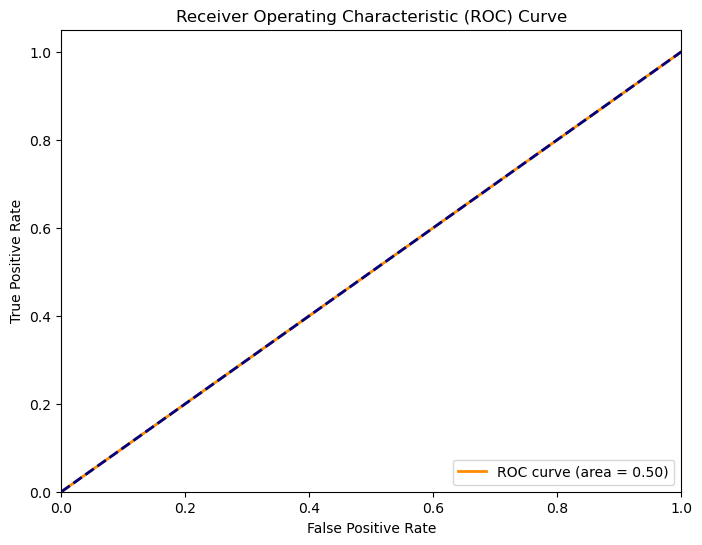

5_stack Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.52        54

    accuracy                           0.35       154
   macro avg       0.18      0.50      0.26       154
weighted avg       0.12      0.35      0.18       154



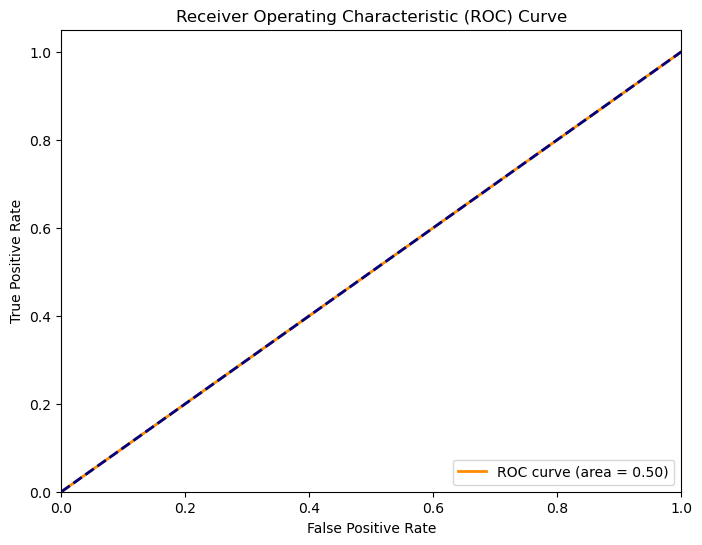

In [ ]:
# Output
report_val = classification_report(y_val, y_val_pred_5_stack, output_dict=True)
auc_val = roc_auc_score(y_val, y_val_proba_5_stack)
print("5_stack Validation Classification Report:")
print(classification_report(y_val, y_val_pred_5_stack))
get_roc_auc(y_val, y_val_pred_5_stack)


report_test = classification_report(y_test, y_test_pred_5_stack, output_dict=True)
auc_test = roc_auc_score(y_test, y_test_proba_5_stack)
print("5_stack Test Classification Report:")
print(classification_report(y_test, y_test_pred_5_stack))
get_roc_auc(y_test, y_test_pred_5_stack)

results.append({
    "model": "5_stack",
    "val_result": report_val,
    "val_auc": float(auc_val),
    "test_result": report_test,
    "test_auc": float(auc_test),
})

# Ranking Models

In [ ]:
def extract_metrics(row, split="val"):
    rep = row[f"{split}_result"]
    acc = rep.get("accuracy", float("nan"))
    f1_macro = rep.get("macro avg", {}).get("f1-score", float("nan"))
    prec_macro = rep.get("macro avg", {}).get("precision", float("nan"))
    rec_macro = rep.get("macro avg", {}).get("recall", float("nan"))
    auc = row.get(f"{split}_auc", float("nan"))
    return pd.Series({
        f"acc_{split}": acc,
        f"f1_macro_{split}": f1_macro,
        f"prec_macro_{split}": prec_macro,
        f"rec_macro_{split}": rec_macro,
        f"auc_{split}": auc,
    })

df = pd.DataFrame(results)

# Add columns for val/test metrics
df = pd.concat([df, df.apply(extract_metrics, axis=1, split="val")], axis=1)
df = pd.concat([df, df.apply(extract_metrics, axis=1, split="test")], axis=1)

w_f1, w_auc, w_acc = 0.5, 0.3, 0.2

# Get the mean of val & test
df["f1_macro_mean"] = (df["f1_macro_val"] + df["f1_macro_test"]) / 2
df["auc_mean"]      = (df["auc_val"] + df["auc_test"]) / 2
df["acc_mean"]      = (df["acc_val"] + df["acc_test"]) / 2

# weighted composite score
df["score"] = (
    w_f1 * df["f1_macro_mean"] +
    w_auc * df["auc_mean"] +
    w_acc * df["acc_mean"]
)

ranked = df.sort_values(by="score", ascending=False).reset_index(drop=True)

In [ ]:
from tabulate import tabulate

ranked_display = ranked.drop(columns=["val_result", "test_result"])

print(tabulate(ranked_display, headers="keys", tablefmt="psql"))

+----+---------------------+-----------+------------+-----------+----------------+------------------+-----------------+-----------+------------+-----------------+-------------------+------------------+------------+-----------------+------------+------------+----------+
|    | model               |   val_auc |   test_auc |   acc_val |   f1_macro_val |   prec_macro_val |   rec_macro_val |   auc_val |   acc_test |   f1_macro_test |   prec_macro_test |   rec_macro_test |   auc_test |   f1_macro_mean |   auc_mean |   acc_mean |    score |
|----+---------------------+-----------+------------+-----------+----------------+------------------+-----------------+-----------+------------+-----------------+-------------------+------------------+------------+-----------------+------------+------------+----------|
|  0 | tree_margin         |  0.853396 |   0.786852 |  0.784314 |       0.766736 |         0.762523 |        0.772925 |  0.853396 |   0.727273 |        0.695136 |          0.699423 |        

# Predicting Diabetes

In [ ]:
# Getting Data
target = pd.read_csv('diabetes2.csv')

target.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,0.0
mean,5.100000,120.500000,64.800000,16.600000,64.700000,31.05000,0.469900,34.000000,NaN
std,4.306326,37.310261,25.406911,16.480291,75.234522,5.12624,0.273708,10.811516,NaN
min,0.000000,82.000000,0.000000,0.000000,0.000000,21.10000,0.088000,23.000000,NaN
25%,2.250000,94.750000,64.500000,0.000000,0.000000,28.75000,0.293000,25.250000,NaN
50%,4.000000,108.500000,70.000000,17.000000,32.000000,32.00000,0.400500,30.000000,NaN
75%,6.750000,130.000000,77.000000,28.750000,133.500000,34.72500,0.706750,41.000000,NaN
max,14.000000,195.000000,88.000000,44.000000,184.000000,36.80000,0.905000,55.000000,NaN


In [ ]:
# Splitting Dependent from Independent variable
predict_column = "Outcome"

X_predict = target.drop(columns=[predict_column])

In [ ]:
# Predicting the values for diabetes
y_predicted = best_xg_boost_pipe.predict(X_predict)
print(y_predicted)

# Reshaping for the predicted Y to be fitted into the original dataset
y_predicted_reshaped = y_predicted.reshape(-1,1)

target['Outcome'] = y_predicted_reshaped

[0 1 0 0 1 1 1 0 1 0]


In [ ]:
target

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,93,50,30,64,28.7,0.356,23,0
1,4,109,64,44,99,34.8,0.905,26,1
2,14,100,78,25,184,36.6,0.412,46,0
3,3,82,70,0,0,21.1,0.389,25,0
4,7,195,70,33,145,25.1,0.163,55,1
5,1,173,74,0,0,36.8,0.088,38,1
6,4,127,88,11,155,34.5,0.598,28,1
7,10,108,66,0,0,32.4,0.272,42,0
8,0,131,88,0,0,31.6,0.743,32,1
9,2,87,0,23,0,28.9,0.773,25,0
